<a href="https://colab.research.google.com/github/cleitonhentges/Praticas-de-python/blob/Atividade---Visualiza%C3%A7%C3%A3o-de-Dados-em-Python/Atividade_Implementa%C3%A7%C3%A3o_pr%C3%A1tica_de_%C3%81rvores_de_Decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.tree import plot_tree

df = pd.read_csv('/content/CREDIT_SCORE_PROJETO_PARTE1 (1).csv', delimiter=';')
df.head(20)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


In [4]:

#Checagem de valores nulos.
valores_nulos = df.isnull().sum()
print(valores_nulos)

#Estou deletando menores de 18 anos e pessoas que não cadastraram a idade.
df = df[df['Age'] >= 18].dropna(subset=['Age'])
df = df[df['Age'] != 'nan'].dropna(subset=['Age'])

valores_nulos = df.isnull().sum()
print(valores_nulos)

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64
Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


In [5]:
import pandas as pd

#Checagem de dados incorretos

print(df['Gender'].unique())

print(df['Education'].unique())

print(df['Marital Status'].unique())

print(df['Number of Children'].unique())

print(df['Home Ownership'].unique())

print(df['Credit Score'].unique())

print(df['Age'].unique())

# Ganho anual
df['Income'] = df['Income'].str.replace('.', '').str.replace(',', '.').astype(float)


['Female' 'Male']
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
['Single' 'Married']
[0 2 1 3]
['Rented' 'Owned']
['High' 'Average' 'Low']
[25. 30. 35. 40. 45. 50. 26. 31. 43. 48. 53. 29. 34. 39. 44. 49. 36. 41.
 46. 51. 27. 32. 37. 42. 47. 52. 28. 33. 38.]


In [6]:
#Traduzindo níveis de ensino
df['Education'].value_counts()
print(df['Education'].value_counts())

df['Education_Categoria'] = df['Education']

df['Education_Categoria'] = df['Education_Categoria'].replace({
    'Bachelor\'s Degree':'Bacharel',
    'Master\'s Degree':'Mestrado',
    'Doctorate':'Doutorado',
    'High School Diploma':'Diploma do Ensino Médio',
    'Associate\'s Degree':'Grau de Associado',
})

df['Education_Categoria'].value_counts()
print(df['Education_Categoria'].value_counts())


Education
Bachelor's Degree      34
Master's Degree        30
Doctorate              24
High School Diploma    22
Associate's Degree     20
Name: count, dtype: int64
Education_Categoria
Bacharel                   34
Mestrado                   30
Doutorado                  24
Diploma do Ensino Médio    22
Grau de Associado          20
Name: count, dtype: int64


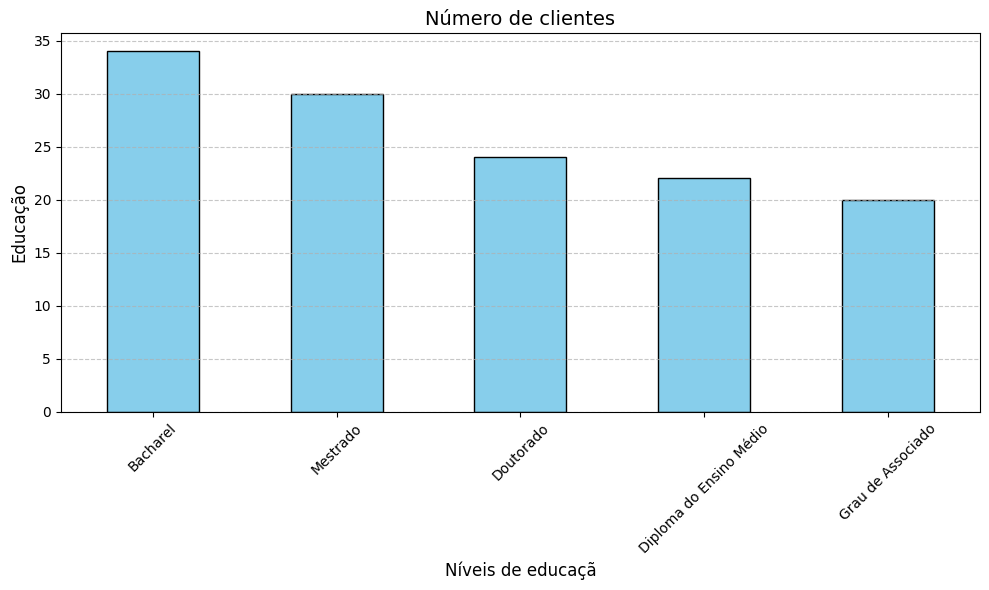

In [7]:
#Análise Univariada - Educação Acadêmica

Education_Categoria = df['Education_Categoria']

plt.figure(figsize=(10, 6))
df['Education_Categoria'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Número de clientes", fontsize=14)
plt.xlabel("Níveis de educaçã", fontsize=12)
plt.ylabel("Educação", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
df.describe(include='all')

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score,Education_Categoria
count,130.000000,130,130.000000,130,130,130.000000,130,130,130
unique,NaN,2,NaN,5,2,NaN,2,3,5
top,NaN,Female,NaN,Bachelor's Degree,Married,NaN,Owned,High,Bacharel
freq,NaN,68,NaN,34,68,NaN,86,88,34
mean,37.507692,NaN,84288.461538,NaN,NaN,0.661538,NaN,NaN,NaN
std,8.500110,NaN,33063.942361,NaN,NaN,0.902656,NaN,NaN,NaN
min,25.000000,NaN,25000.000000,NaN,NaN,0.000000,NaN,NaN,NaN
25%,30.000000,NaN,58125.000000,NaN,NaN,0.000000,NaN,NaN,NaN
50%,36.000000,NaN,82500.000000,NaN,NaN,0.000000,NaN,NaN,NaN
75%,45.000000,NaN,105000.000000,NaN,NaN,1.000000,NaN,NaN,NaN


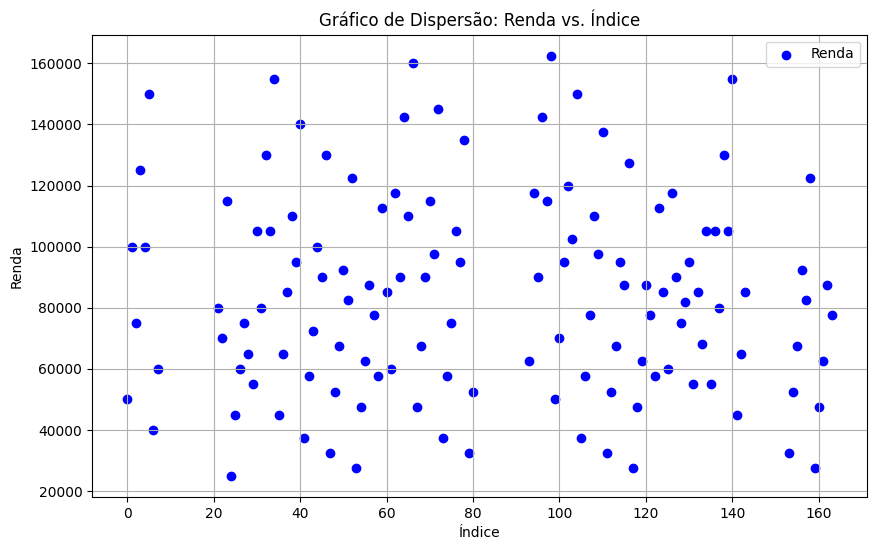

In [9]:
#Análise Univariada - Renda

x = df['Income'].index
y = df['Income']

plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Income'], color='blue', label='Renda')
plt.xlabel('Índice')
plt.ylabel('Renda')
plt.title('Gráfico de Dispersão: Renda vs. Índice')
plt.legend()
plt.grid(True)


Não nota-se destacado nenhum outlier. variações padrões de salário.


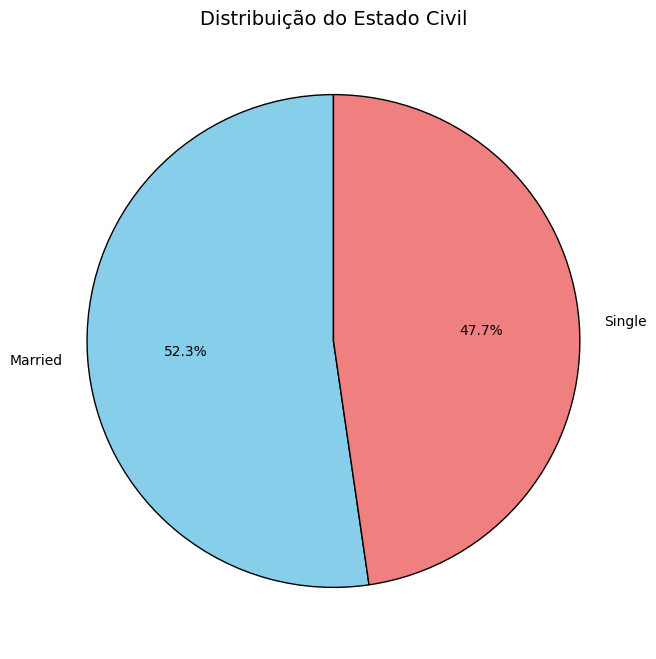

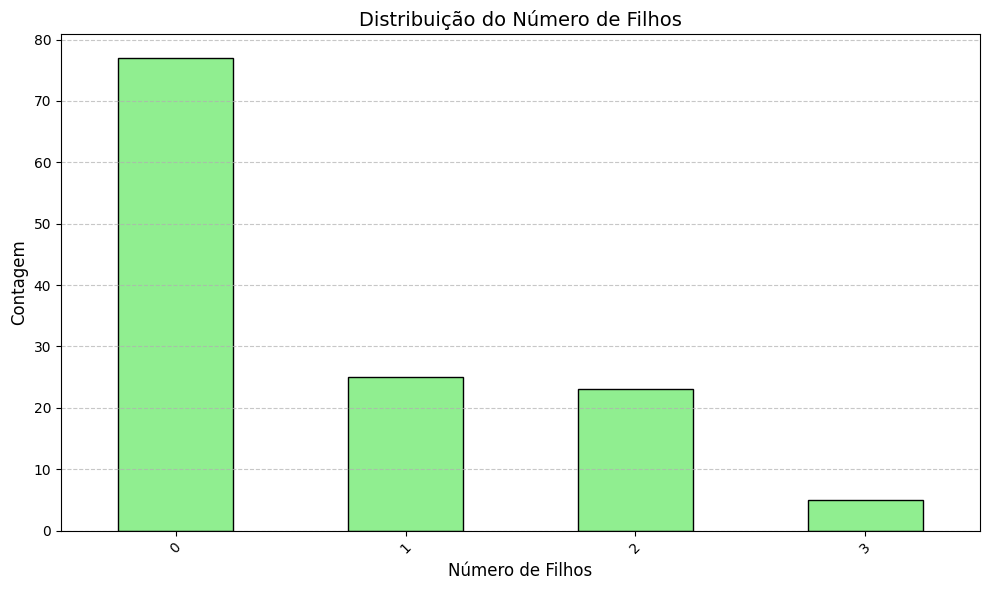

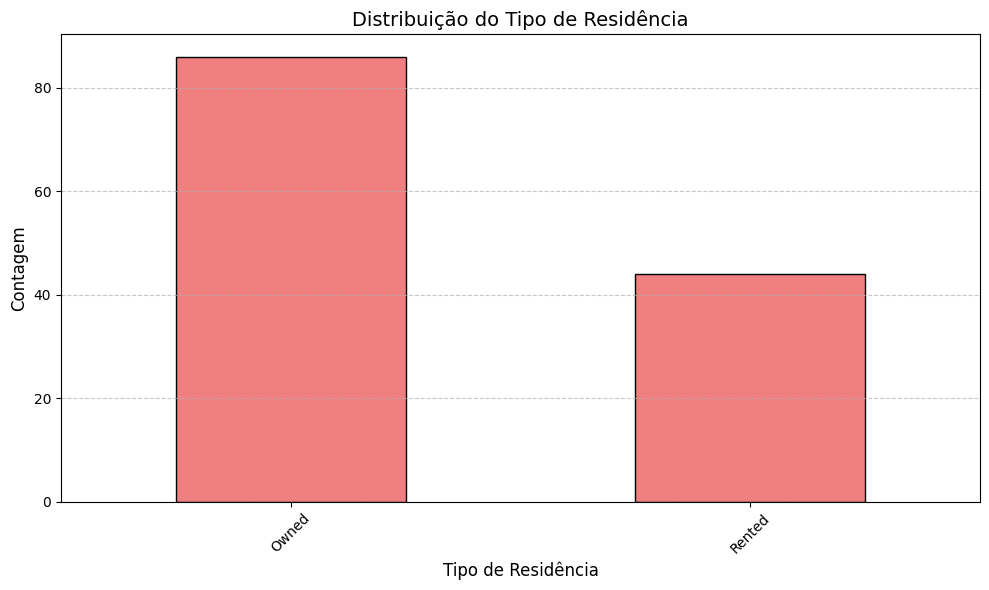

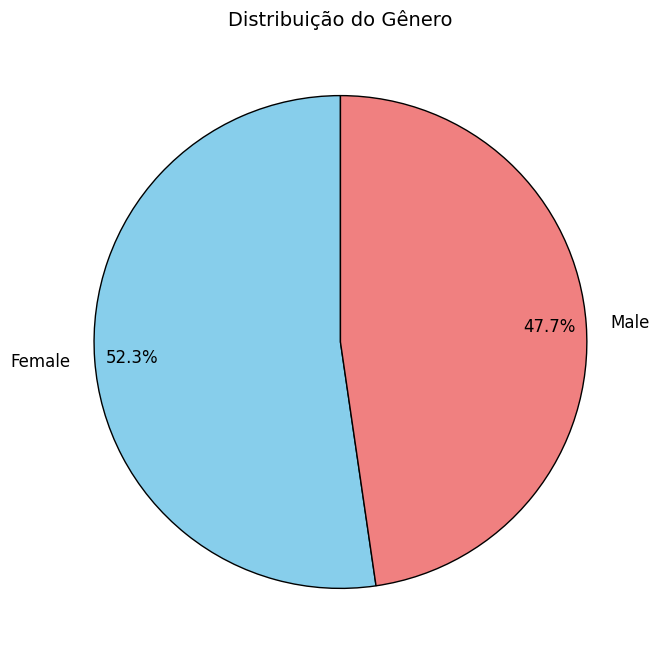

In [10]:

# Análise Univariada (Estado Civil)

plt.figure(figsize=(8, 8))
df['Marital Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'],
                                         startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Distribuição do Estado Civil", fontsize=14)
plt.ylabel("")
plt.show()

# Análise Univariada (Número de Filhos)
plt.figure(figsize=(10, 6))
df['Number of Children'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Distribuição do Número de Filhos", fontsize=14)
plt.xlabel("Número de Filhos", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise Univariada (Tipo de Residência)

#df['Home Ownership'].value_counts()
#print(df['Home Ownership'].value_counts())

df['Home Ownership'] = df['Home Ownership'].replace({
    0: 'Alugada',
    1: 'Própria',
})

plt.figure(figsize=(10, 6))
df['Home Ownership'].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Distribuição do Tipo de Residência", fontsize=14)
plt.xlabel("Tipo de Residência", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise Univariada (Genero)
plt.figure(figsize=(8, 8))
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue', 'lightcoral'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    pctdistance=0.85,
    textprops={'fontsize': 12}
)

plt.title("Distribuição do Gênero", fontsize=14)
plt.ylabel("")
plt.show()


# * **Estado Civil**: Observar a proporção entre os diferentes estados civis pode indicar tendências demográficas.
# * **Número de Filhos**:  Ajuda a entender o perfil familiar dos clientes, se há uma predominância de famílias com ou sem filhos, ou com muitos filhos.
# * **Tipo de Residência**:  Pode fornecer informações sobre o nível socioeconômico e estabilidade dos clientes.
# * **Gênero**: Permite analisar se há diferenças significativas entre homens e mulheres no contexto dos dados, podendo ser relevante para estratégias de marketing direcionadas.


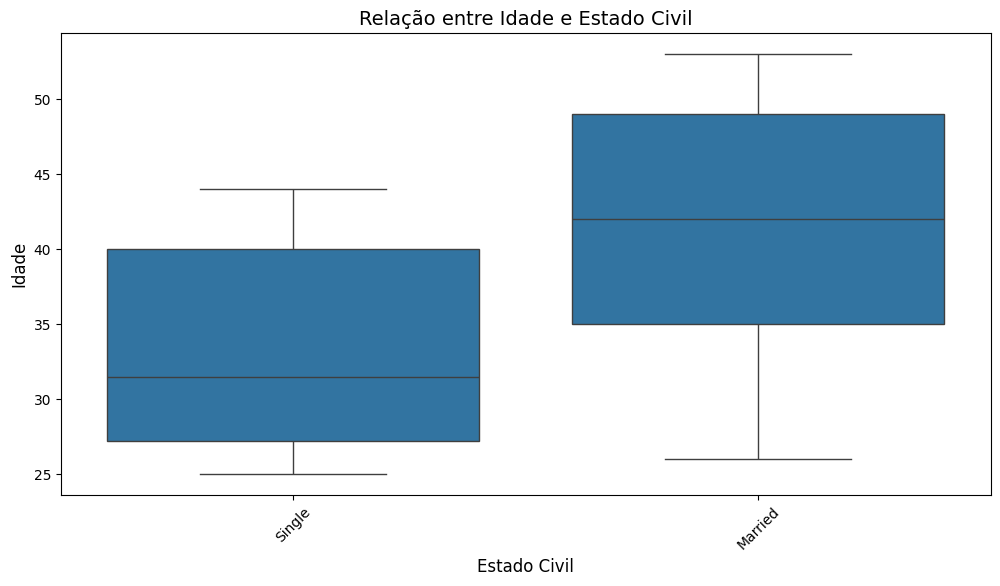

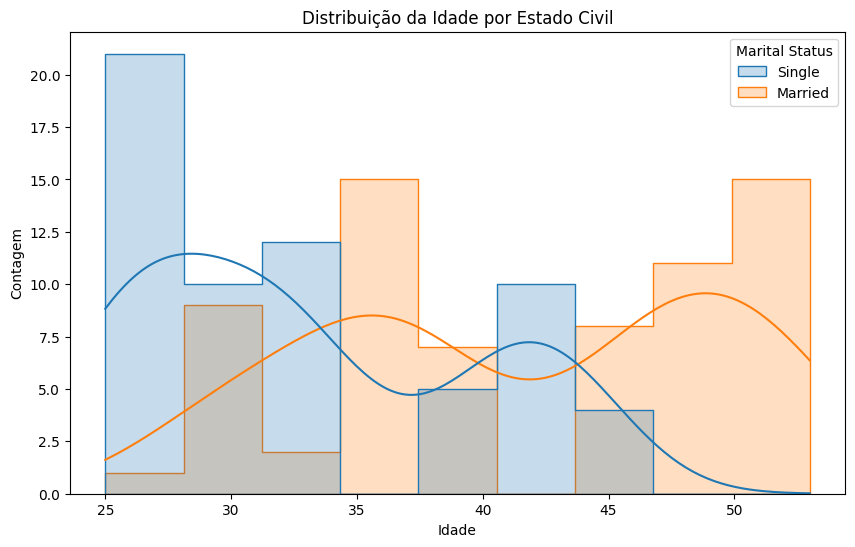

[1 0]


In [11]:

# Análise Bivariada (Idade vs estado civil)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Marital Status', y='Age', data=df)
plt.title('Relação entre Idade e Estado Civil', fontsize=14)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição da idade por estado civil
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Marital Status', kde=True, element="step")
plt.title('Distribuição da Idade por Estado Civil')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

#Calcular a correlação entre idade e estado civil
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Marital_Status_Num'] = le.fit_transform(df['Marital Status'])
print(df['Marital_Status_Num'].unique())

correlacao = df['Age'].corr(df['Marital_Status_Num'])
#print(f"A correlação entre idade e estado civil é: {correlacao}")



Pessoas mais velhas tem intuito de formar famílias enquanto pessoas mais novas buscam formação profissional e são mais abertos a novas experiências.

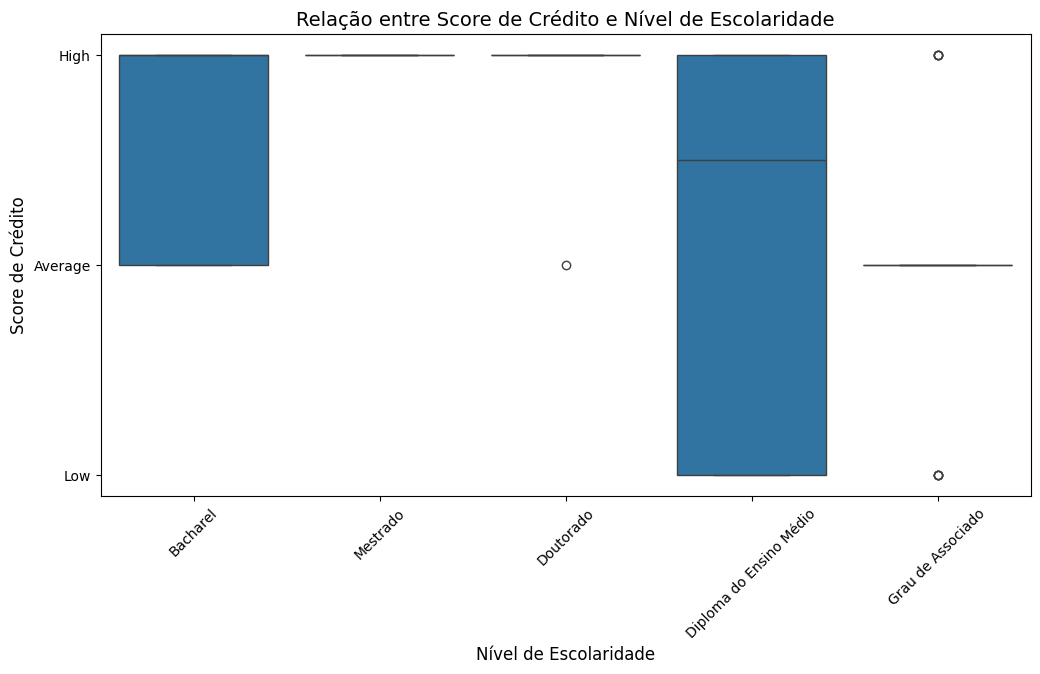

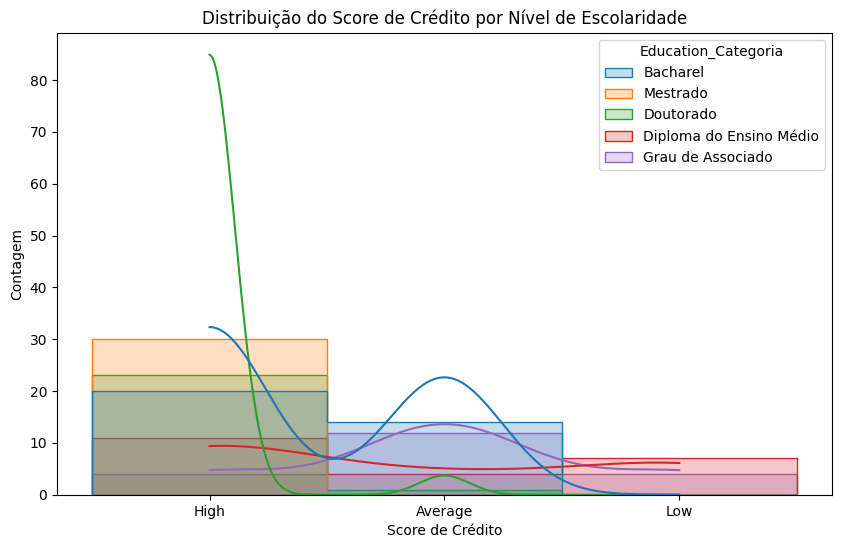

In [12]:
# Análise Bivariada (Score de Crédito vs escolaridade)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Categoria', y='Credit Score', data=df)
plt.title('Relação entre Score de Crédito e Nível de Escolaridade', fontsize=14)
plt.xlabel('Nível de Escolaridade', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição do score de crédito por nível de escolaridade
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Credit Score', hue='Education_Categoria', kde=True, element="step")
plt.title('Distribuição do Score de Crédito por Nível de Escolaridade')
plt.xlabel('Score de Crédito')
plt.ylabel('Contagem')
plt.show()

Pessoas de ensino superior e mais tendem a ganhar mais e obter mais margem de crédito.

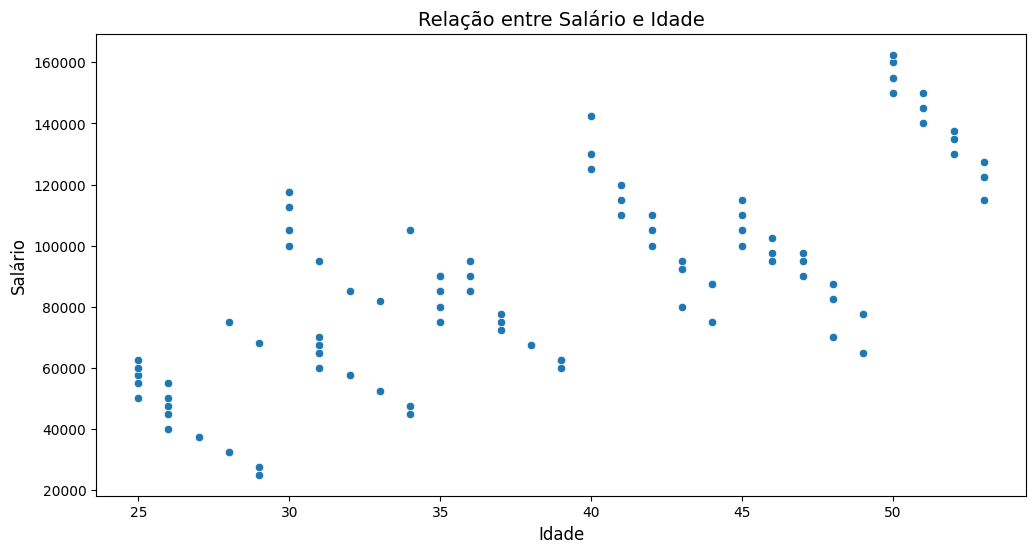

Correlação entre salário e idade: 0.6852131825495968


In [13]:
# Análise Bivariada (Salário vs idade)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age', y='Income', data=df)
plt.title('Relação entre Salário e Idade', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Salário', fontsize=12)
plt.show()

# Cálculo da correlação entre salário e idade
correlation = df['Age'].corr(df['Income'])
print(f"Correlação entre salário e idade: {correlation}")


Entre idades o salário pode haver uma disparidade e alguns se destacam pelo volume mas em uma visão geral é uma oscilação natural do mercado em ver que cargos mais altos não tem tantas vagas.

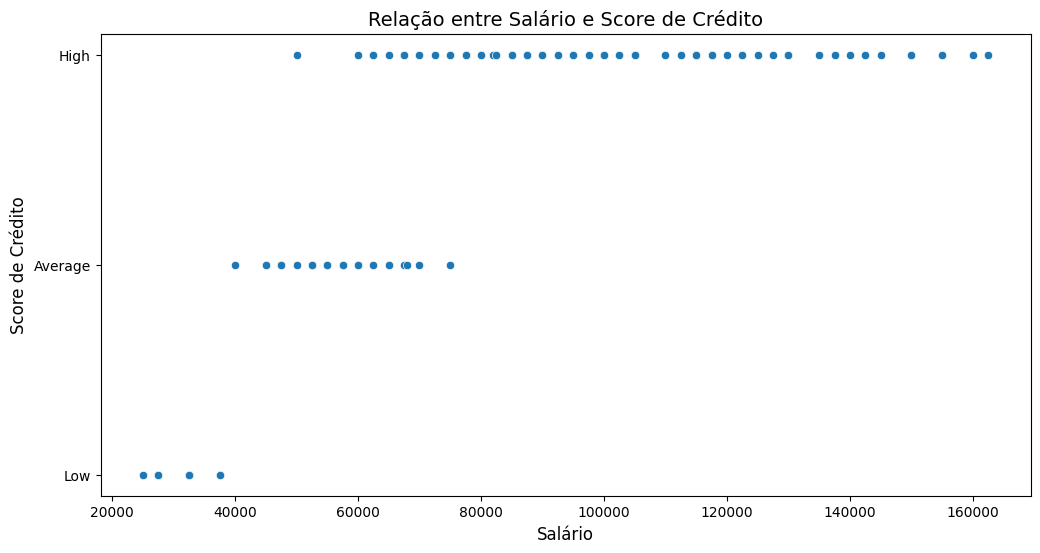

Correlação entre salário e Score de Crédito: 0.13029566289092967


In [14]:
# Análise Bivariada (Salário vs score de Crédito)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Income', y='Credit Score', data=df)
plt.title('Relação entre Salário e Score de Crédito', fontsize=14)
plt.xlabel('Salário', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.show()


# Cálculo da correlação entre salário e Score de Crédito
# Convertendo Credit Score em valores numéricos;
if df['Credit Score'].dtype == object:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df['Credit_Score_Num'] = le.fit_transform(df['Credit Score'])
    correlation = df['Income'].corr(df['Credit_Score_Num'])
else:
    correlation = df['Income'].corr(df['Credit Score'])

print(f"Correlação entre salário e Score de Crédito: {correlation}")


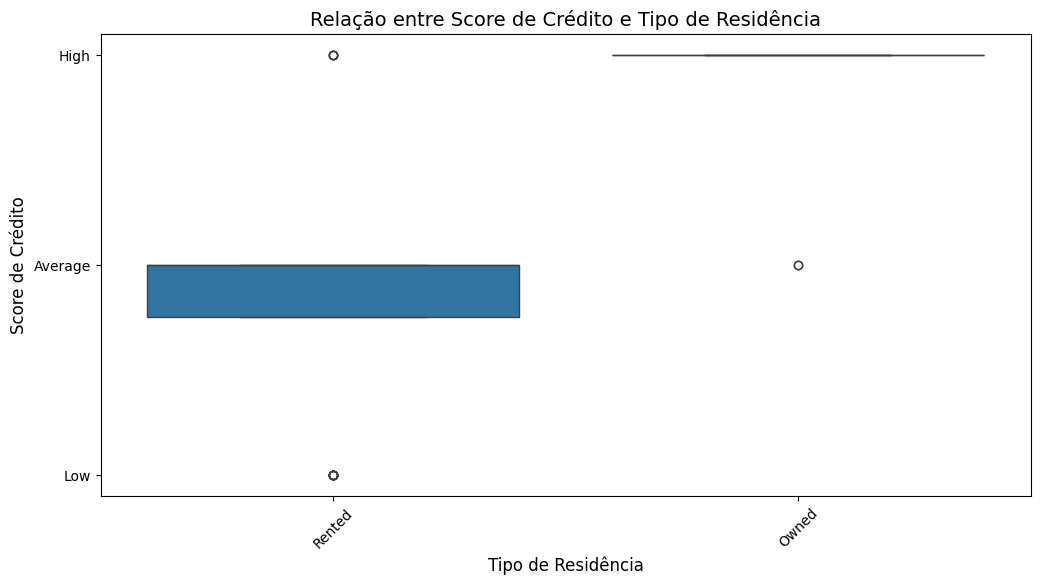

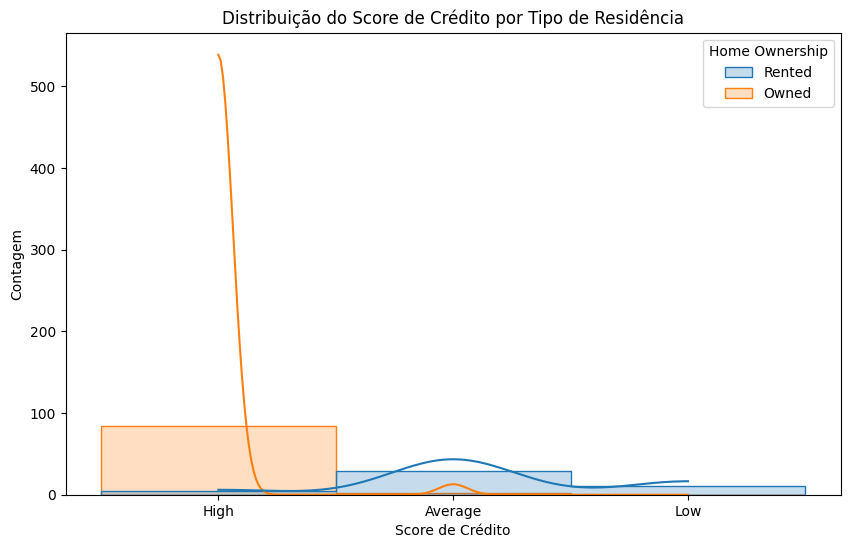

Correlação entre tipo de residência e Score de Crédito: 0.13029566289092967


In [15]:
# Análise Bivariada (Score de Crédito vs tipo de residência)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Home Ownership', y='Credit Score', data=df)
plt.title('Relação entre Score de Crédito e Tipo de Residência', fontsize=14)
plt.xlabel('Tipo de Residência', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição do score de crédito por tipo de residência
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Credit Score', hue='Home Ownership', kde=True, element="step")
plt.title('Distribuição do Score de Crédito por Tipo de Residência')
plt.xlabel('Score de Crédito')
plt.ylabel('Contagem')
plt.show()

# Calcular a correlação entre 'Home Ownership' e 'Credit Score'
# Converter a variável categórica 'Home Ownership' em numérica usando Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Home Ownership'] = le.fit_transform(df['Home Ownership'])

print(f"Correlação entre tipo de residência e Score de Crédito: {correlation}")

In [16]:
# Balanceamento de Classes
from imblearn.over_sampling import SMOTE

# Separar features (X) e target (y)
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

# Converter atributos categóricos em numéricos usando Label Encoding
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

# Aplicar SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Divisão em treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Shapes após o balanceamento e divisão:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes após o balanceamento e divisão:
X_train: (211, 10)
X_test: (53, 10)
y_train: (211,)
y_test: (53,)


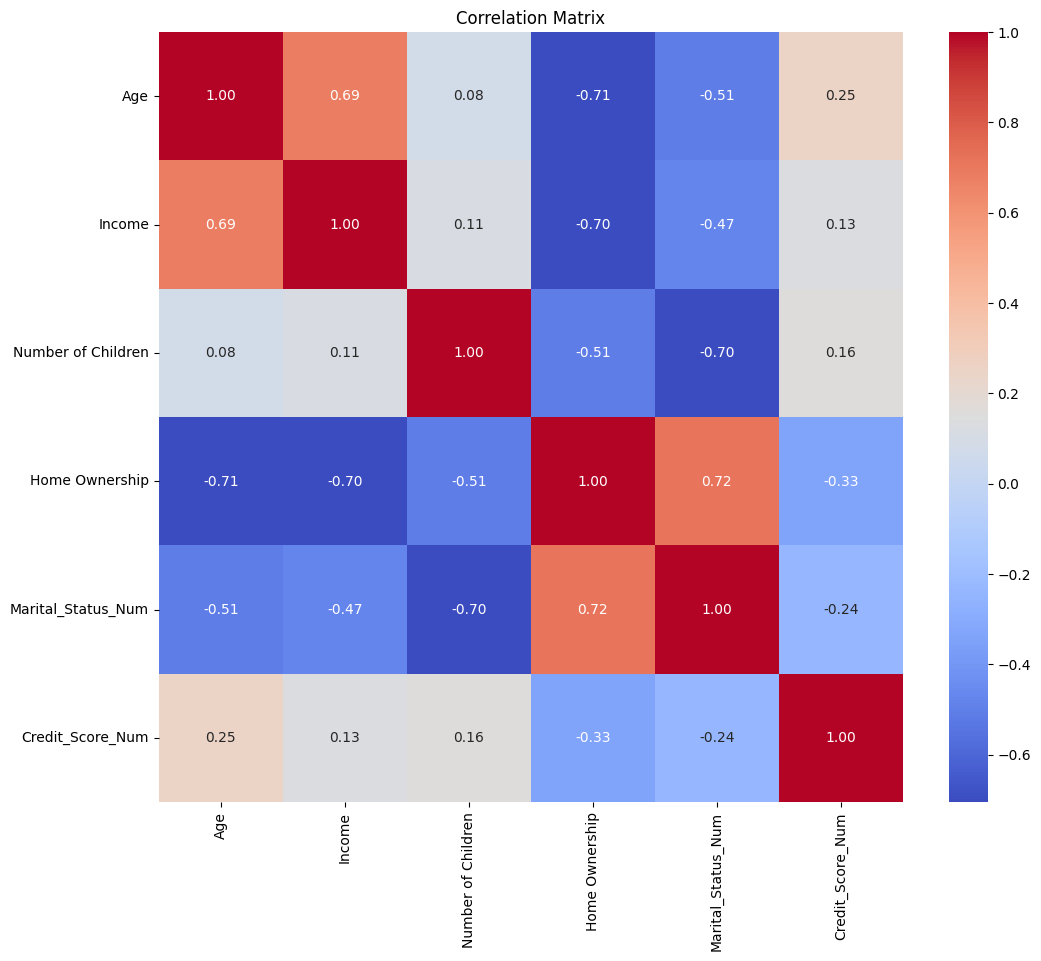

In [17]:
# Calculando a matriz de correlação
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

#Plotando a matriz de correlação usando um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Existe uma alta correlação entre idade e salário e pessoas que ganham mais ou tem anos de experiência ou profissões que exigem formação acadêmica.
Pessoas mais velhas buscam formar uma família e logo adquirem uma casa própria, explicasse assim a alta correlação entre Marital Status e Home Ownership.

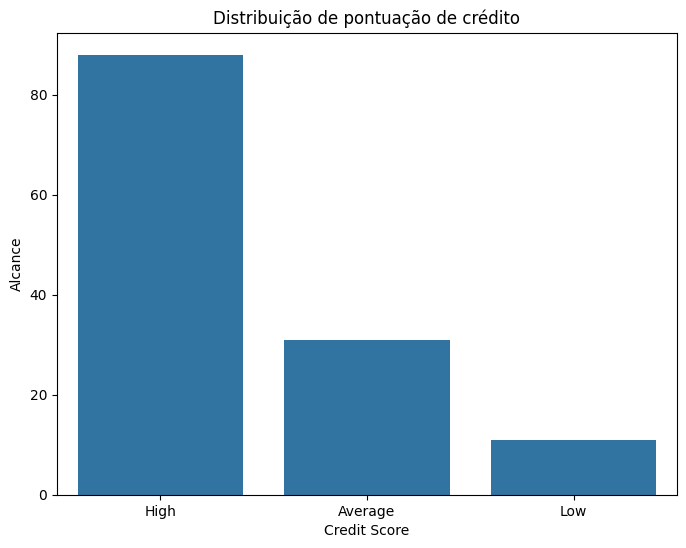

Credit Score
High       88
Average    31
Low        11
Name: count, dtype: int64


In [18]:
# Verifique o saldo da pontuação de crédito
plt.figure(figsize=(8, 6))
sns.countplot(x='Credit Score', data=df)
plt.title('Distribuição de pontuação de crédito')
plt.xlabel('Credit Score')
plt.ylabel('Alcance')
plt.show()

# Contagem de valores para cada categoria de pontuação de crédito
print(df['Credit Score'].value_counts())


In [19]:
from imblearn.over_sampling import RandomOverSampler

X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

#Convertendo recursos categóricos em numéricos usando Label Encoding
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

#Balanceado dados
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Distribução de balanceamento
print(pd.Series(y_resampled).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

#print("Shapes after balancing and splitting:")
#print("X_train:", X_train.shape)
#print("X_test:", X_test.shape)
#print("y_train:", y_train.shape)
#print("y_test:", y_test.shape)


Credit Score
High       88
Average    88
Low        88
Name: count, dtype: int64


Accuracy on test set: 1.0
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        16
        High       1.00      1.00      1.00        19
         Low       1.00      1.00      1.00        18

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weighted avg       1.00      1.00      1.00        53



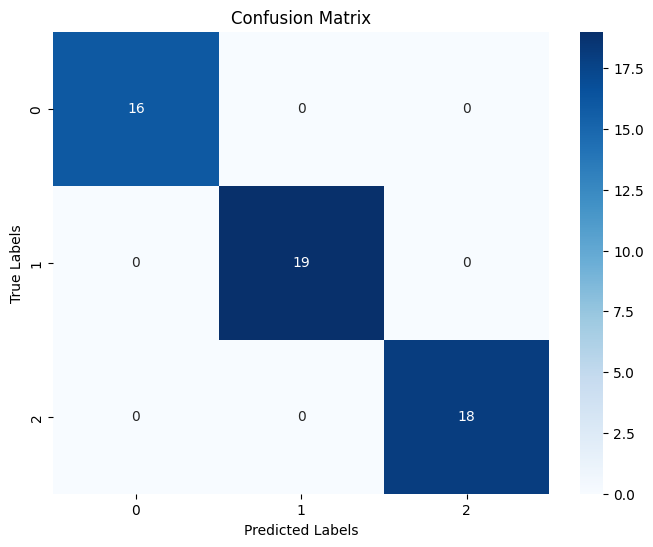

-Precisão do treinamento: 100.00%
-Diferença entre treinamento e precisão do teste: 0.00%
Model Evaluation Analysis:
-The model achieved an accuracy of 100.00% on the test data.

Classification Report:
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        16
        High       1.00      1.00      1.00        19
         Low       1.00      1.00      1.00        18

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weighted avg       1.00      1.00      1.00        53


Confusion Matrix Analysis:
[[16  0  0]
 [ 0 19  0]
 [ 0  0 18]]

Training vs. Testing Performance:
-Training Accuracy: 100.00%
-Test Accuracy: 100.00%
-Difference: 0.00%
-The difference between training and test accuracies is within an acceptable range.


In [31]:
#Árvore de decisão

from sklearn.tree import DecisionTreeClassifier

# Crie um classificador de árvore de decisão
clf = DecisionTreeClassifier(criterion='gini', random_state=0)

# Treine o classificador com os dados de treinamento
clf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Determinando  'X_test', 'y_test'

#Previsões futuras do conjunto de testes
y_pred = clf.predict(X_test)

#Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy}")

#Relatório de classificação
print(classification_report(y_test, y_pred))

# Matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

training_accuracy = accuracy_score(y_train, clf.predict(X_train))
print(f"-Precisão do treinamento: {training_accuracy*100:.2f}%")
print(f"-Diferença entre treinamento e precisão do teste: {(training_accuracy - accuracy)*100:.2f}%")

# prompt: Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

# Avaliação e Comparação

print("Model Evaluation Analysis:")
print(f"-The model achieved an accuracy of {accuracy*100:.2f}% on the test data.")

# Analise o relatório de classificação
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Análise detalhada do relatório de classificação
#Analise a precisão, o recall e a pontuação F1 para cada classe.
#A baixa precisão de uma classe indica muitos falsos positivos.
#Baixo recall para uma classe indica muitos falsos negativos.
# Pontuação F1 baixa sugere um desequilíbrio entre precisão e recall.


#Analise a matriz de confusão
print("\nConfusion Matrix Analysis:")
print(conf_matrix)

#Examine a matriz de confusão para obter insights sobre tipos específicos de erros.
#Os elementos diagonais representam instâncias classificadas corretamente.
#Elementos fora da diagonal mostram classificações incorretas.  Por exemplo, um valor alto em uma célula específica fora da diagonal indica uma confusão frequente entre duas classes.

#Compare o desempenho de treinamento e teste
print("\nTraining vs. Testing Performance:")
print(f"-Training Accuracy: {training_accuracy*100:.2f}%")
print(f"-Test Accuracy: {accuracy*100:.2f}%")
print(f"-Difference: {(training_accuracy - accuracy)*100:.2f}%")

#Análise de overfitting
if (training_accuracy - accuracy) > 0.1:
    print("-Significant difference between training and test accuracy suggests potential overfitting.")
    print("-Consider using techniques like regularization, pruning, or gathering more data to mitigate overfitting.")
elif (training_accuracy - accuracy) < 0 :
    print("-The test accuracy is better than the train accuracy, this can happen due to randomness in the train_test_split function.")
else:
    print("-The difference between training and test accuracies is within an acceptable range.")

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=y.unique().astype(str), rounded=True)
plt.show()



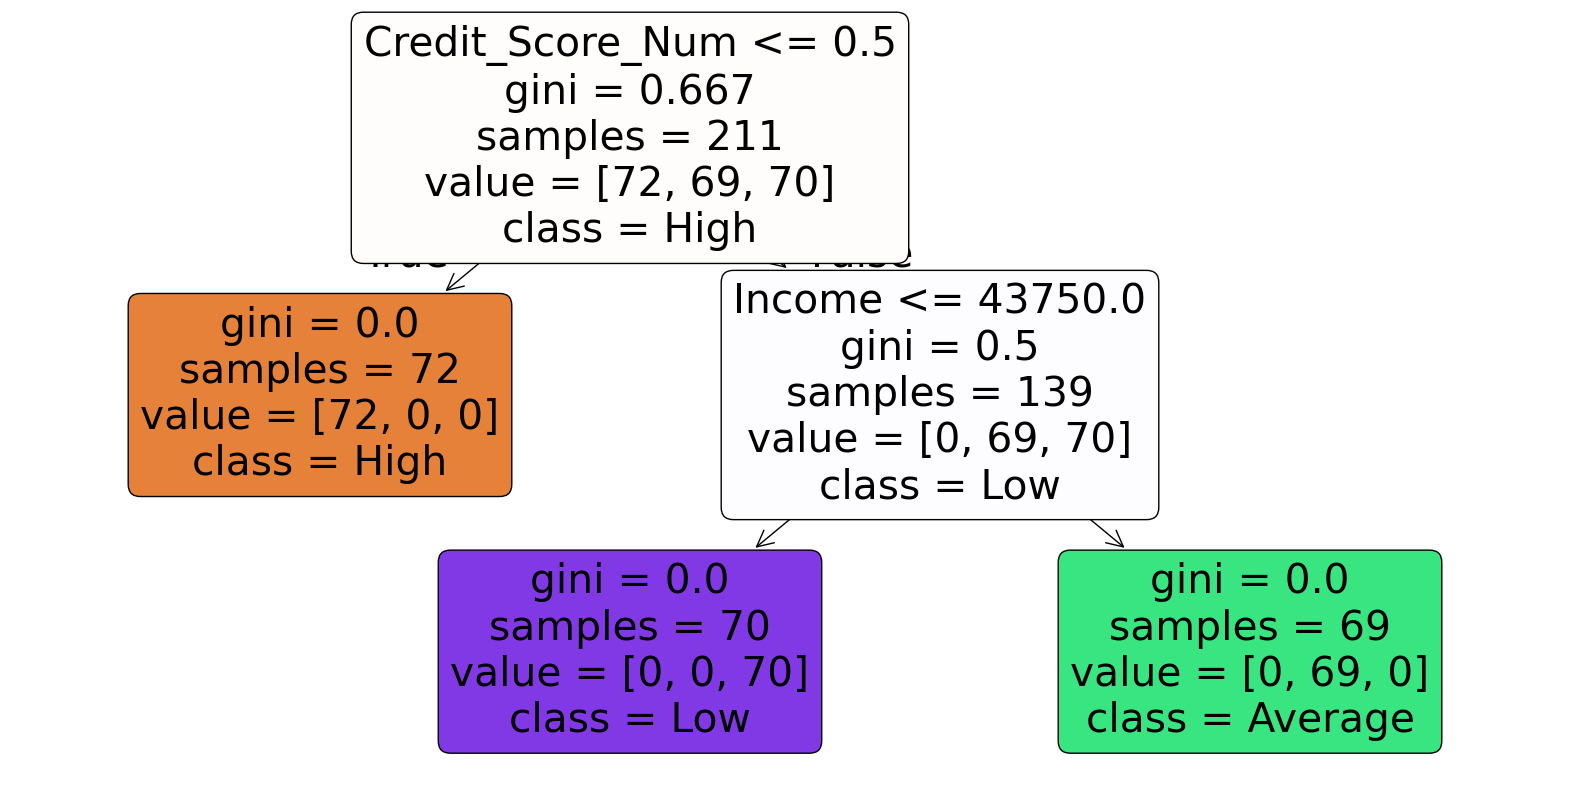

Os dois principais recursos correlacionados com a pontuação de crédito:


,Credit_Score_Num
Home Ownership,0.333658
Age,0.252615


In [35]:
# Árvore de decisão
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=y.unique().astype(str), rounded=True)
plt.show()

#Calcule a matriz de correlação para os itens
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

# Identifique os dois recursos com a maior correlação absoluta com a 'Pontuação de Crédito'
credit_score_correlations = correlation_matrix['Credit_Score_Num'].drop('Credit_Score_Num')
principais_dois_recursos = credit_score_correlations.abs().nlargest(2)

print("Os dois principais recursos correlacionados com a pontuação de crédito:")
principais_dois_recursos

Acurácia do modelo com as duas principais features: 0.9811320754716981
              precision    recall  f1-score   support

     Average       0.94      1.00      0.97        16
        High       1.00      0.95      0.97        19
         Low       1.00      1.00      1.00        18

    accuracy                           0.98        53
   macro avg       0.98      0.98      0.98        53
weighted avg       0.98      0.98      0.98        53



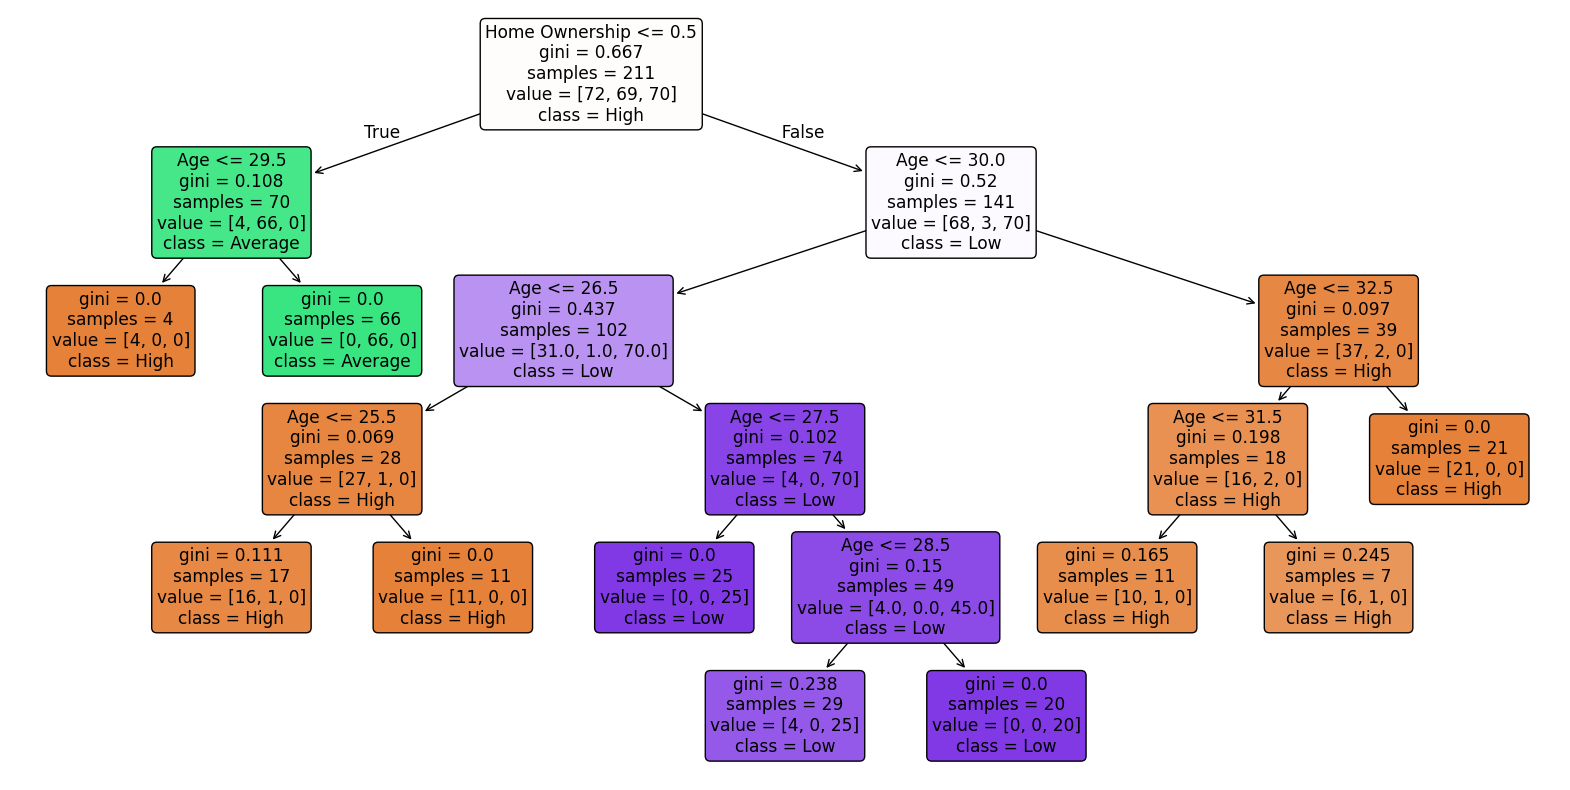

Acurácia do modelo anterior: 1.0
Acurácia do modelo com as duas principais features: 0.9811320754716981
O desempenho da árvore com as duas principais features está pior que o modelo anterior.
A perda de informação devido à redução da dimensionalidade pode ter prejudicado a acurácia do modelo.


In [36]:
# Seleciona as duas principais features
X_top2 = X_resampled[principais_dois_recursos.index]

# Divide os dados em treino e teste novamente, usando as duas principais features
X_train_top2, X_test_top2, y_train_top2, y_test_top2 = train_test_split(X_top2, y_resampled, test_size=0.2, random_state=42)

# Cria e treina um novo modelo de árvore de decisão com as duas principais features
clf_top2 = DecisionTreeClassifier(criterion='gini', random_state=0)
clf_top2.fit(X_train_top2, y_train_top2)

# Faz previsões com o novo modelo
y_pred_top2 = clf_top2.predict(X_test_top2)

# Avalia o novo modelo
accuracy_top2 = accuracy_score(y_test_top2, y_pred_top2)
print(f"Acurácia do modelo com as duas principais features: {accuracy_top2}")
print(classification_report(y_test_top2, y_pred_top2))

# Plota a árvore de decisão
plt.figure(figsize=(20,10))
plot_tree(clf_top2, filled=True, feature_names=X_top2.columns, class_names=y.unique().astype(str), rounded=True)
plt.show()

# Comparação de desempenho
print(f"Acurácia do modelo anterior: {accuracy}")
print(f"Acurácia do modelo com as duas principais features: {accuracy_top2}")

if accuracy_top2 > accuracy:
  print("O desempenho da árvore com as duas principais features está melhor que o modelo anterior.")
  print("A redução na dimensionalidade pode ter ajudado a evitar o overfitting e simplificar o modelo, mantendo um bom nível de acurácia.")
elif accuracy_top2 < accuracy:
  print("O desempenho da árvore com as duas principais features está pior que o modelo anterior.")
  print("A perda de informação devido à redução da dimensionalidade pode ter prejudicado a acurácia do modelo.")
else:
  print("O desempenho dos dois modelos é igual.")
  print("Neste caso, a escolha do melhor modelo pode depender de outros fatores como complexidade e interpretabilidade.")

8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

Entre naive Bayes e árvore de decisão os resultados de teste coincidiram com 1.0 tendo como treinamento:

Árvore de decisão : 1.0

Naive Bayes       : 0.995260663507109

Visivelmente a Árvore de decisão se mostrou mais eficiente em comparação de treinamento.
